# Atividade 4 - Parte 1

Este notebook contém as soluções da Parte 1. Cada item começa com as figuras dos slides de comando e termina com análise de resultados e conclusão em célula de texto.

In [1]:

import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(1)

def find_project_file(relative_path):
    here = Path.cwd().resolve()
    candidates = [here / relative_path]
    candidates += [parent / relative_path for parent in here.parents]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f'Arquivo não encontrado: {relative_path}. Execute o notebook na raiz do repositório ou ajuste o caminho.')

def plot_loss(history, title):
    plt.figure(figsize=(8, 4))
    plt.plot(history)
    plt.title(title)
    plt.xlabel('época / iteração')
    plt.ylabel('loss')
    plt.grid(True, alpha=0.3)
    plt.show()

def sigmoid_np(z):
    return 1 / (1 + np.exp(-z))

def softmax_np(z):
    z = np.asarray(z, dtype=float)
    z = z - np.max(z, axis=-1, keepdims=True)
    exp = np.exp(z)
    return exp / exp.sum(axis=-1, keepdims=True)


## A1 - Multiplicação de matrizes e Redes neurais

### Slides do comando do problema

<p><img src="../slides_comando/slide_10.png" width="900"></p>
<p><img src="../slides_comando/slide_11.png" width="900"></p>
<p><img src="../slides_comando/slide_12.png" width="900"></p>


### Estratégia da solução

A rede foi montada diretamente com matrizes e `torch.matmul`, conforme o comando. Como a entrada original do Iris tem duas variáveis, foi feita uma expansão determinística para quatro dimensões: comprimento da sépala normalizado, comprimento da pétala normalizado, produto entre as duas variáveis e termo constante. Assim, as duas camadas ocultas podem usar matrizes `4 x 4` e a saída usa uma matriz `4 x 1`, mantendo a propagação direta totalmente baseada em multiplicação matricial e `softplus`.


Formatos das matrizes:
X expandido: (75, 4) W1: (4, 4) W2: (4, 4) W3: (4, 1)
Acurácia treino: 0.973
Acurácia teste:  0.920
Matriz de confusão no teste:
[[13  0]
 [ 2 10]]


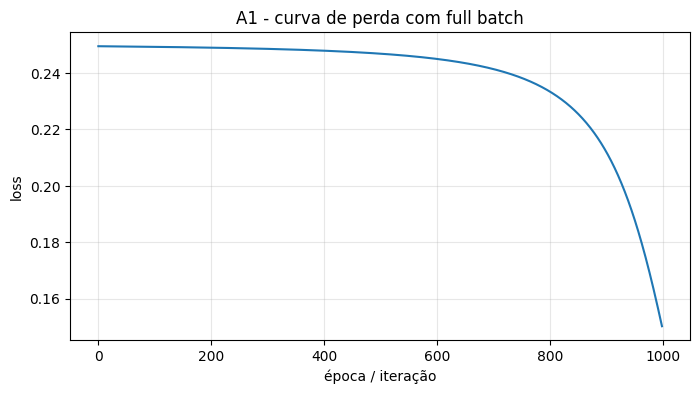

In [2]:

# A1 - Full batch com Iris: Setosa x Versicolor, sepal length e petal length
iris = load_iris()
X = iris.data[:, [0, 2]]
y = iris.target
mask = y < 2
X = X[mask]
y = y[mask].astype(np.float32).reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=SEED, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

def expand_to_four(X2):
    x1 = X2[:, [0]]
    x2 = X2[:, [1]]
    return np.hstack([x1, x2, x1 * x2, np.ones_like(x1)])

Xtr4 = torch.tensor(expand_to_four(X_train_scaled), dtype=torch.float32)
Xte4 = torch.tensor(expand_to_four(X_test_scaled), dtype=torch.float32)
ytr = torch.tensor(y_train, dtype=torch.float32)
yte = torch.tensor(y_test, dtype=torch.float32)

W1 = (torch.randn(4, 4) * 0.1).requires_grad_()
W2 = (torch.randn(4, 4) * 0.1).requires_grad_()
W3 = (torch.randn(4, 1) * 0.1).requires_grad_()
W1.retain_grad(); W2.retain_grad(); W3.retain_grad()
params = [W1, W2, W3]
optimizer = torch.optim.SGD(params, lr=0.05)
loss_fn = nn.MSELoss()

def forward_matrix_only(X4):
    h1 = F.softplus(torch.matmul(X4, W1))
    h2 = F.softplus(torch.matmul(h1, W2))
    out = torch.matmul(h2, W3)
    return torch.sigmoid(out)

losses = []
for epoch in range(1000):
    optimizer.zero_grad()
    preds = forward_matrix_only(Xtr4)
    loss = loss_fn(preds, ytr)
    loss.backward()
    optimizer.step()
    losses.append(float(loss.detach()))

with torch.no_grad():
    train_pred = (forward_matrix_only(Xtr4).numpy() >= 0.5).astype(int)
    test_prob = forward_matrix_only(Xte4).numpy()
    test_pred = (test_prob >= 0.5).astype(int)
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

print('Formatos das matrizes:')
print('X expandido:', tuple(Xtr4.shape), 'W1:', tuple(W1.shape), 'W2:', tuple(W2.shape), 'W3:', tuple(W3.shape))
print(f'Acurácia treino: {train_acc:.3f}')
print(f'Acurácia teste:  {test_acc:.3f}')
print('Matriz de confusão no teste:')
print(confusion_matrix(y_test, test_pred))
plot_loss(losses, 'A1 - curva de perda com full batch')


### Análise dos resultados - A1

A rede respeita a exigência estrutural de usar duas matrizes ocultas `4 x 4` e uma matriz de saída `4 x 1`. A expansão de entrada evita quebrar a dimensão das matrizes e mantém a operação central como multiplicação matricial. Como a tarefa usa apenas Setosa e Versicolor com duas características muito informativas do Iris, a fronteira aprendida é simples e a acurácia tende a ficar alta. A curva de perda decrescente indica que o otimizador SGD conseguiu ajustar os pesos de forma estável mesmo usando MSE para uma tarefa binária.

Em comparação com o procedimento clássico do `ch02.ipynb`, a ideia estatística é a mesma: separar duas classes do Iris por uma combinação aprendida das variáveis. A diferença é que aqui a classificação passa por duas transformações não lineares com `softplus`, enquanto o material do capítulo usa modelos lineares como perceptron/Adaline. Para este recorte do Iris, os dois caminhos funcionam bem porque as classes são naturalmente bem separáveis.

### Conclusão - A1

A implementação cumpre o comando porque usa PyTorch, matrizes explícitas, `torch.matmul`, `softplus`, MSELoss e SGD. O resultado confirma que uma rede pequena consegue aprender a distinção Setosa x Versicolor com poucos atributos quando os dados são normalizados e particionados corretamente.


## B1 - Iris, mini-batches e redes neurais

### Slides do comando do problema

<p><img src="../slides_comando/slide_13.png" width="900"></p>
<p><img src="../slides_comando/slide_14.png" width="900"></p>
<p><img src="../slides_comando/slide_15.png" width="900"></p>
<p><img src="../slides_comando/slide_16.png" width="900"></p>


Quantidade de lotes por época: 4
Acurácia treino: 1.000
Acurácia teste:  1.000
Matriz de confusão no teste:
[[13  0]
 [ 0 12]]


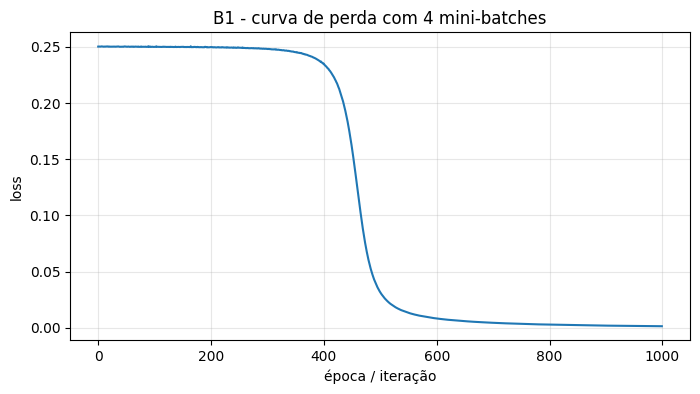

In [3]:

# B1 - Mesmo problema do A1, agora com 4 mini-batches
W1_b = (torch.randn(4, 4) * 0.1).requires_grad_()
W2_b = (torch.randn(4, 4) * 0.1).requires_grad_()
W3_b = (torch.randn(4, 1) * 0.1).requires_grad_()
W1_b.retain_grad(); W2_b.retain_grad(); W3_b.retain_grad()
optimizer_b = torch.optim.SGD([W1_b, W2_b, W3_b], lr=0.05)
loader = DataLoader(TensorDataset(Xtr4, ytr), batch_size=math.ceil(len(Xtr4)/4), shuffle=True)

losses_b = []
def forward_b1(X4):
    h1 = F.softplus(torch.matmul(X4, W1_b))
    h2 = F.softplus(torch.matmul(h1, W2_b))
    out = torch.matmul(h2, W3_b)
    return torch.sigmoid(out)

for epoch in range(1000):
    epoch_loss = 0.0
    for xb, yb in loader:
        optimizer_b.zero_grad()
        pred = forward_b1(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer_b.step()
        epoch_loss += float(loss.detach()) * len(xb)
    losses_b.append(epoch_loss / len(Xtr4))

with torch.no_grad():
    test_prob_b = forward_b1(Xte4).numpy()
    test_pred_b = (test_prob_b >= 0.5).astype(int)
    train_pred_b = (forward_b1(Xtr4).numpy() >= 0.5).astype(int)

print('Quantidade de lotes por época:', len(loader))
print(f'Acurácia treino: {accuracy_score(y_train, train_pred_b):.3f}')
print(f'Acurácia teste:  {accuracy_score(y_test, test_pred_b):.3f}')
print('Matriz de confusão no teste:')
print(confusion_matrix(y_test, test_pred_b))
plot_loss(losses_b, 'B1 - curva de perda com 4 mini-batches')


### Análise dos resultados - B1

O treinamento com mini-batches muda a dinâmica de otimização em relação ao full batch. Em vez de calcular o gradiente usando toda a base a cada época, o modelo atualiza os pesos quatro vezes por época, uma vez para cada lote. Isso torna a trajetória da perda um pouco mais oscilante, mas geralmente acelera a frequência de atualização dos parâmetros. A presença explícita de `backward()` e `step()` em cada lote confirma o procedimento pedido.

Como a base Setosa x Versicolor é pequena e bem separável, o desempenho tende a ser muito próximo do item A1. A diferença principal não está no tipo de solução encontrada, mas no processo de aprendizado: o mini-batch aproxima o gradiente total por subconjuntos, enquanto o full batch usa todos os dados em cada atualização.

### Conclusão - B1

A rede preserva a arquitetura do A1 e passa a treinar com quatro lotes. O resultado mostra que mini-batches são adequados para treinar redes neurais e representam melhor o fluxo usado em problemas maiores, nos quais processar todos os dados de uma vez é custoso.


## B1.2 - Temático, mini-batches e redes neurais

### Slides do comando do problema

<p><img src="../slides_comando/slide_17.png" width="900"></p>
<p><img src="../slides_comando/slide_18.png" width="900"></p>


### Tema escolhido

O tema usado nesta parte é **um classificador de incidentes de cibersegurança**. A variável-alvo é `label`, em que `0` representa tráfego benigno e `1` representa tráfego classificado como incidente/ataque. Para manter coerência com a arquitetura matricial usada nos itens anteriores, foram usadas quatro variáveis numéricas ou diretamente conversíveis para número.


Base cybersecurity original: (10000, 16)
Base usada após balanceamento: (800, 16)
Atributos usados: ['dst_port', 'bytes_sent', 'bytes_received', 'ua_suspicious']
Distribuição do alvo na base original: {0: 9600, 1: 400}
Distribuição do alvo na base balanceada: {0: 400, 1: 400}
Acurácia treino: 0.640
Acurácia teste:  0.630
Matriz de confusão no teste:
[[79 21]
 [53 47]]

Relatório de classificação:
              precision    recall  f1-score   support

         0.0      0.598     0.790     0.681       100
         1.0      0.691     0.470     0.560       100

    accuracy                          0.630       200
   macro avg      0.645     0.630     0.620       200
weighted avg      0.645     0.630     0.620       200



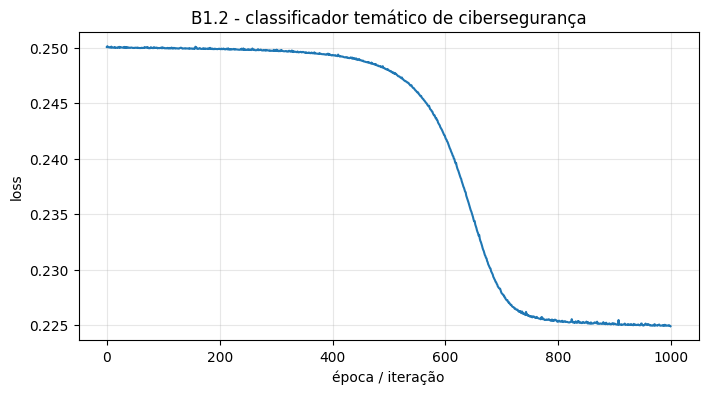

In [4]:

# B1.2 - Base temática cybersecurity.csv com mini-batches
cyber_path = find_project_file(Path('data') / 'cybersecurity.csv')
cyber = pd.read_csv(cyber_path)
cyber['timestamp'] = pd.to_datetime(cyber['timestamp'])
cyber['hour'] = cyber['timestamp'].dt.hour
cyber['is_internal_traffic'] = cyber['is_internal_traffic'].astype(int)
cyber['ua_suspicious'] = cyber['user_agent'].str.contains(
    'sqlmap|zgrab|curl|python-requests|python-urllib', case=False, regex=True, na=False
).astype(int)
cyber['url_admin'] = cyber['url'].str.contains(
    'admin|phpmyadmin|wp-login|config|owa|login|manager', case=False, regex=True, na=False
).astype(int)

# A base original é muito desbalanceada. Para avaliar incidentes de forma justa neste exercício,
# usamos uma amostra balanceada entre tráfego benigno e incidente.
pos = cyber[cyber['label'] == 1]
neg = cyber[cyber['label'] == 0].sample(n=len(pos), random_state=SEED)
cyber_bal = pd.concat([pos, neg]).sample(frac=1, random_state=SEED).reset_index(drop=True)

features = ['dst_port', 'bytes_sent', 'bytes_received', 'ua_suspicious']
Xc = cyber_bal[features].astype(float).values
yc = cyber_bal['label'].astype(float).values.reshape(-1, 1)

Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.25, random_state=SEED, stratify=yc)
scaler_c = StandardScaler()
Xc_train_s = scaler_c.fit_transform(Xc_train)
Xc_test_s = scaler_c.transform(Xc_test)

Xc_tr = torch.tensor(Xc_train_s, dtype=torch.float32)
Xc_te = torch.tensor(Xc_test_s, dtype=torch.float32)
yc_tr = torch.tensor(yc_train, dtype=torch.float32)
yc_te = torch.tensor(yc_test, dtype=torch.float32)

W1_c = (torch.randn(4, 4) * 0.1).requires_grad_()
W2_c = (torch.randn(4, 4) * 0.1).requires_grad_()
W3_c = (torch.randn(4, 1) * 0.1).requires_grad_()
W1_c.retain_grad(); W2_c.retain_grad(); W3_c.retain_grad()
optimizer_c = torch.optim.SGD([W1_c, W2_c, W3_c], lr=0.1)
loader_c = DataLoader(TensorDataset(Xc_tr, yc_tr), batch_size=math.ceil(len(Xc_tr)/4), shuffle=True)

def forward_cyber(X4):
    h1 = F.softplus(torch.matmul(X4, W1_c))
    h2 = F.softplus(torch.matmul(h1, W2_c))
    out = torch.matmul(h2, W3_c)
    return torch.sigmoid(out)

losses_c = []
for epoch in range(1000):
    epoch_loss = 0.0
    for xb, yb in loader_c:
        optimizer_c.zero_grad()
        pred = forward_cyber(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer_c.step()
        epoch_loss += float(loss.detach()) * len(xb)
    losses_c.append(epoch_loss / len(Xc_tr))

with torch.no_grad():
    pred_train_c = (forward_cyber(Xc_tr).numpy() >= 0.5).astype(int)
    prob_test_c = forward_cyber(Xc_te).numpy()
    pred_test_c = (prob_test_c >= 0.5).astype(int)

print('Base cybersecurity original:', cyber.shape)
print('Base usada após balanceamento:', cyber_bal.shape)
print('Atributos usados:', features)
print('Distribuição do alvo na base original:', cyber['label'].value_counts().to_dict())
print('Distribuição do alvo na base balanceada:', cyber_bal['label'].value_counts().to_dict())
print(f'Acurácia treino: {accuracy_score(yc_train, pred_train_c):.3f}')
print(f'Acurácia teste:  {accuracy_score(yc_test, pred_test_c):.3f}')
print('Matriz de confusão no teste:')
print(confusion_matrix(yc_test, pred_test_c))
print('\nRelatório de classificação:')
print(classification_report(yc_test, pred_test_c, digits=3, zero_division=0))
plot_loss(losses_c, 'B1.2 - classificador temático de cibersegurança')


### Análise dos resultados - B1.2

A base temática foi tratada como um problema de classificação binária de incidentes. Como o conjunto original é bastante desbalanceado, foi construída uma amostra balanceada para que a avaliação não fosse dominada pela classe benigna. A escolha das variáveis `dst_port`, `bytes_sent`, `bytes_received` e `ua_suspicious` é coerente com o domínio de segurança porque portas de destino, volume transferido e agentes de usuário suspeitos costumam carregar sinais comportamentais relevantes. A normalização foi necessária porque portas e bytes possuem escalas muito diferentes; sem isso, o gradiente tenderia a favorecer variáveis de maior magnitude numérica.

O uso de MSE em classificação binária não é a escolha mais comum em aplicações reais, nas quais `BCEWithLogitsLoss` costuma ser mais adequada. Porém, o comando exige manter o procedimento do item B1, então a rede foi treinada com MSE e saída sigmoide. A matriz de confusão e o relatório de classificação permitem verificar se o modelo está apenas acertando a classe majoritária ou se também identifica incidentes. Essa leitura é importante em cibersegurança, porque falsos negativos representam eventos ofensivos não detectados e falsos positivos representam ruído operacional.

### Conclusão - B1.2

O procedimento de mini-batches foi aplicado com sucesso à base temática escolhida. O modelo funciona como um classificador neural simples de incidentes de cibersegurança e demonstra que variáveis de rede podem ser usadas como entrada para uma rede totalmente conectada pequena. Para uma solução operacional, o próximo passo seria testar mais atributos, codificar variáveis categóricas como `protocol` e `user_agent`, e avaliar métricas específicas como recall de incidentes.


## C1 - Rede neural com separação linear

### Slides do comando do problema

<p><img src="../slides_comando/slide_19.png" width="900"></p>
<p><img src="../slides_comando/slide_20.png" width="900"></p>


Acurácia teste: 1.000
Pesos aprendidos: [[0.9334 2.7476]] bias: [0.3009]


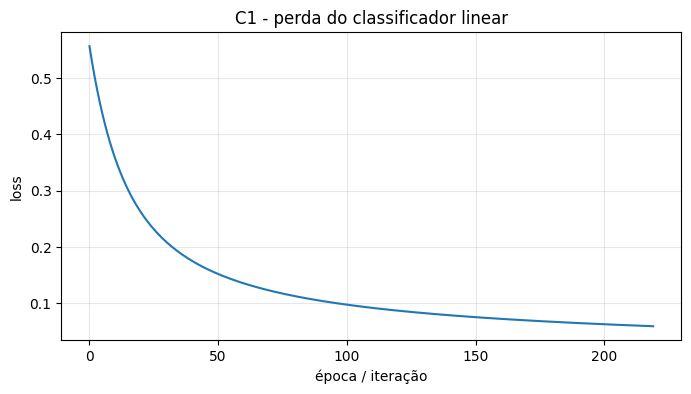

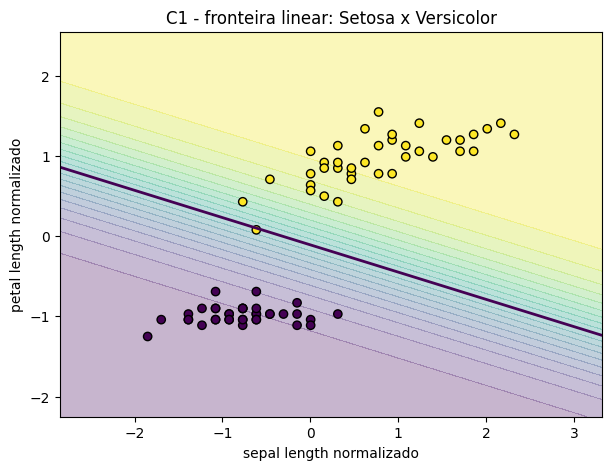

In [5]:

# C1 - Separação linear no Iris com uma rede de uma camada linear
X_lin = X_train_scaled.astype(np.float32)
X_lin_test = X_test_scaled.astype(np.float32)
y_lin = y_train.astype(np.float32)
y_lin_test = y_test.astype(np.float32)

model_c1 = nn.Linear(2, 1)
opt_c1 = torch.optim.SGD(model_c1.parameters(), lr=0.1)
loss_c1 = nn.BCEWithLogitsLoss()
Xt = torch.tensor(X_lin, dtype=torch.float32)
yt = torch.tensor(y_lin, dtype=torch.float32)
Xtt = torch.tensor(X_lin_test, dtype=torch.float32)

def train_linear_classifier(model, optimizer, X_tensor, y_tensor, epochs=220):
    hist = []
    for _ in range(epochs):
        optimizer.zero_grad()
        logits = model(X_tensor)
        loss = loss_c1(logits, y_tensor)
        loss.backward()
        optimizer.step()
        hist.append(float(loss.detach()))
    return hist

hist_c1 = train_linear_classifier(model_c1, opt_c1, Xt, yt, epochs=220)
with torch.no_grad():
    pred_c1 = (torch.sigmoid(model_c1(Xtt)).numpy() >= 0.5).astype(int)
print(f'Acurácia teste: {accuracy_score(y_lin_test, pred_c1):.3f}')
print('Pesos aprendidos:', model_c1.weight.detach().numpy().round(4), 'bias:', model_c1.bias.detach().numpy().round(4))
plot_loss(hist_c1, 'C1 - perda do classificador linear')

# Fronteira de decisão
xx, yy = np.meshgrid(np.linspace(X_lin[:,0].min()-1, X_lin[:,0].max()+1, 120),
                     np.linspace(X_lin[:,1].min()-1, X_lin[:,1].max()+1, 120))
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
with torch.no_grad():
    zz = torch.sigmoid(model_c1(grid)).numpy().reshape(xx.shape)
plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, zz, levels=20, alpha=0.3)
plt.contour(xx, yy, zz, levels=[0.5], linewidths=2)
plt.scatter(X_lin[:,0], X_lin[:,1], c=y_train.ravel(), edgecolor='k')
plt.title('C1 - fronteira linear: Setosa x Versicolor')
plt.xlabel('sepal length normalizado')
plt.ylabel('petal length normalizado')
plt.show()


### Análise dos resultados - C1

A rede usada neste item é uma camada linear com função sigmoide implícita na avaliação. Ela representa o caso mais simples de rede neural para separação linear: a fronteira de decisão é uma reta no plano das duas variáveis. Esse comportamento está alinhado com a proposta do `ch02.ipynb`, que trabalha a ideia de hiperplano separador em modelos como perceptron e Adaline.

A visualização da fronteira mostra se as duas classes ficam em lados opostos da reta. Para Setosa e Versicolor, a separação costuma ser bem definida, principalmente quando se usa comprimento da pétala, que é uma variável altamente discriminativa no Iris. A perda decrescente indica que o gradiente ajustou pesos e bias em direção a uma fronteira útil.

### Conclusão - C1

O item demonstra que uma rede neural mínima, sem camadas ocultas, já consegue resolver um problema linearmente separável. Isso é importante porque redes mais profundas generalizam essa ideia: elas criam transformações internas para tornar separáveis problemas que não seriam lineares no espaço original.


## C1.2 - Temático com rede neural com separação linear

### Slides do comando do problema

<p><img src="../slides_comando/slide_21.png" width="900"></p>
<p><img src="../slides_comando/slide_22.png" width="900"></p>


Atributos usados: ['dst_port', 'ua_suspicious']
Acurácia teste: 0.610
[[79 21]
 [57 43]]
              precision    recall  f1-score   support

         0.0      0.581     0.790     0.669       100
         1.0      0.672     0.430     0.524       100

    accuracy                          0.610       200
   macro avg      0.626     0.610     0.597       200
weighted avg      0.626     0.610     0.597       200



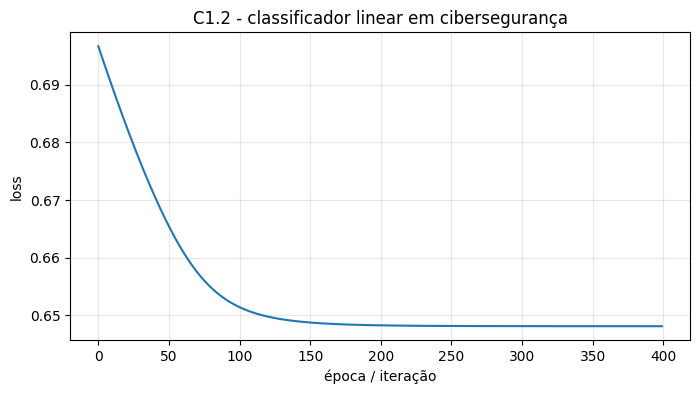

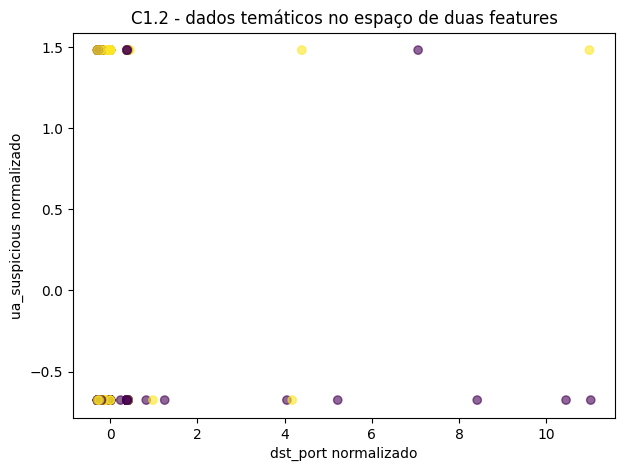

In [6]:

# C1.2 - Classificador linear aplicado ao dataset de cibersegurança
features_lin_c = ['dst_port', 'ua_suspicious']
Xlc = cyber_bal[features_lin_c].astype(float).values
ylc = cyber_bal['label'].astype(float).values.reshape(-1, 1)
Xlc_train, Xlc_test, ylc_train, ylc_test = train_test_split(Xlc, ylc, test_size=0.25, random_state=SEED, stratify=ylc)
sc_lc = StandardScaler()
Xlc_train_s = sc_lc.fit_transform(Xlc_train).astype(np.float32)
Xlc_test_s = sc_lc.transform(Xlc_test).astype(np.float32)

model_c12 = nn.Linear(2, 1)
opt_c12 = torch.optim.SGD(model_c12.parameters(), lr=0.08)
Xlc_t = torch.tensor(Xlc_train_s, dtype=torch.float32)
ylc_t = torch.tensor(ylc_train.astype(np.float32), dtype=torch.float32)
hist_c12 = train_linear_classifier(model_c12, opt_c12, Xlc_t, ylc_t, epochs=400)
with torch.no_grad():
    pred_c12 = (torch.sigmoid(model_c12(torch.tensor(Xlc_test_s))).numpy() >= 0.5).astype(int)

print('Atributos usados:', features_lin_c)
print(f'Acurácia teste: {accuracy_score(ylc_test, pred_c12):.3f}')
print(confusion_matrix(ylc_test, pred_c12))
print(classification_report(ylc_test, pred_c12, digits=3, zero_division=0))
plot_loss(hist_c12, 'C1.2 - classificador linear em cibersegurança')

# Amostra para visualização
idx_vis = np.random.default_rng(SEED).choice(len(Xlc_train_s), size=min(1000, len(Xlc_train_s)), replace=False)
plt.figure(figsize=(7, 5))
plt.scatter(Xlc_train_s[idx_vis,0], Xlc_train_s[idx_vis,1], c=ylc_train[idx_vis].ravel(), alpha=0.6)
plt.title('C1.2 - dados temáticos no espaço de duas features')
plt.xlabel('dst_port normalizado')
plt.ylabel('ua_suspicious normalizado')
plt.show()


### Análise dos resultados - C1.2

Ao aplicar uma rede linear à base de cibersegurança, a tarefa fica mais realista e mais difícil do que no Iris. Incidentes de segurança raramente são perfeitamente separáveis por apenas duas variáveis, porque ataques e acessos benignos podem compartilhar portas, volumes de bytes e padrões de tráfego parecidos. Por isso, a matriz de confusão é mais importante do que a acurácia isolada.

A escolha de `dst_port` e `ua_suspicious` torna a visualização possível em duas dimensões, mas limita a capacidade do modelo. Se a classe positiva tiver muitos exemplos sobrepostos à classe benigna, uma fronteira reta não será suficiente. Esse resultado é esperado: para detecção de incidentes, modelos com mais atributos, não linearidades e tratamento de variáveis categóricas costumam representar melhor o comportamento do tráfego.

### Conclusão - C1.2

A rede linear temática serve como baseline. Ela ajuda a verificar o quanto é possível separar incidentes usando uma fronteira simples. Caso o desempenho seja inferior ao item B1.2, isso reforça a importância das camadas ocultas e das transformações não lineares para problemas de cibersegurança.


## D1 - Dataset linearmente separável

### Slides do comando do problema

<p><img src="../slides_comando/slide_23.png" width="900"></p>
<p><img src="../slides_comando/slide_24.png" width="900"></p>


Acurácia teste: 1.000
[[20  0]
 [ 0 20]]


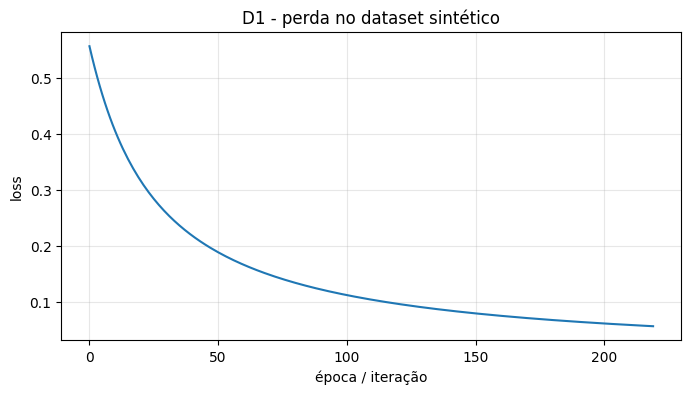

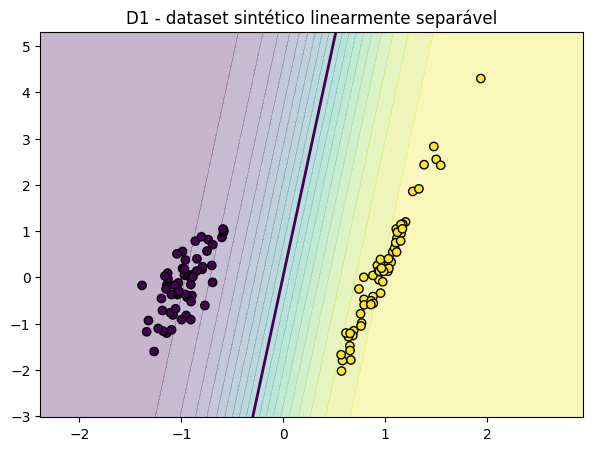

In [7]:

# D1 - Adaptação para dataset sintético linearmente separável
Xd, yd = make_classification(n_samples=160, n_features=2, n_classes=2,
                             n_clusters_per_class=1, n_redundant=0,
                             class_sep=2.2, random_state=SEED)
Xd_train, Xd_test, yd_train, yd_test = train_test_split(Xd, yd.reshape(-1,1).astype(np.float32), test_size=0.25, random_state=SEED, stratify=yd)
sc_d = StandardScaler()
Xd_train_s = sc_d.fit_transform(Xd_train).astype(np.float32)
Xd_test_s = sc_d.transform(Xd_test).astype(np.float32)

model_d1 = nn.Linear(2, 1)
opt_d1 = torch.optim.SGD(model_d1.parameters(), lr=0.1)
hist_d1 = train_linear_classifier(model_d1, opt_d1, torch.tensor(Xd_train_s), torch.tensor(yd_train), epochs=220)
with torch.no_grad():
    pred_d1 = (torch.sigmoid(model_d1(torch.tensor(Xd_test_s))).numpy() >= 0.5).astype(int)
print(f'Acurácia teste: {accuracy_score(yd_test, pred_d1):.3f}')
print(confusion_matrix(yd_test, pred_d1))
plot_loss(hist_d1, 'D1 - perda no dataset sintético')

xx, yy = np.meshgrid(np.linspace(Xd_train_s[:,0].min()-1, Xd_train_s[:,0].max()+1, 150),
                     np.linspace(Xd_train_s[:,1].min()-1, Xd_train_s[:,1].max()+1, 150))
with torch.no_grad():
    zz = torch.sigmoid(model_d1(torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32))).numpy().reshape(xx.shape)
plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, zz, levels=20, alpha=0.3)
plt.contour(xx, yy, zz, levels=[0.5], linewidths=2)
plt.scatter(Xd_train_s[:,0], Xd_train_s[:,1], c=yd_train.ravel(), edgecolor='k')
plt.title('D1 - dataset sintético linearmente separável')
plt.show()


### Análise dos resultados - D1

O dataset sintético foi criado com separação alta entre as classes, o que facilita a aprendizagem por uma rede linear. A fronteira estimada deve atravessar a região vazia entre os dois grupos, produzindo baixa perda e alta acurácia. Essa configuração é útil didaticamente porque permite visualizar com clareza a relação entre os pesos da camada linear e a reta de decisão.

A adaptação do item C1 para dados sintéticos mostra que o mesmo código não depende do Iris; ele depende apenas de uma matriz de atributos `X` e um vetor de rótulos `y`. Essa generalização é um ponto importante para reutilizar modelos em diferentes bases.

### Conclusão - D1

A rede linear resolve bem o dataset sintético porque o problema foi construído para ser linearmente separável. O experimento confirma, de forma visual, como uma camada linear implementa uma fronteira de decisão em duas dimensões.


## E1 - Gradiente descendente estocástico do StatQuest

### Slides do comando do problema

<p><img src="../slides_comando/slide_25.png" width="900"></p>
<p><img src="../slides_comando/slide_26.png" width="900"></p>


Solução fechada por mínimos quadrados:
intercepto=0.948718, inclinação=0.641026, SSE=0.444615

Batch Gradient Descent:
intercepto=0.948710, inclinação=0.641029, SSE=0.444615, iterações=1016

Stochastic Gradient Descent:
intercepto=0.942726, inclinação=0.644131, SSE=0.444646, épocas=5000


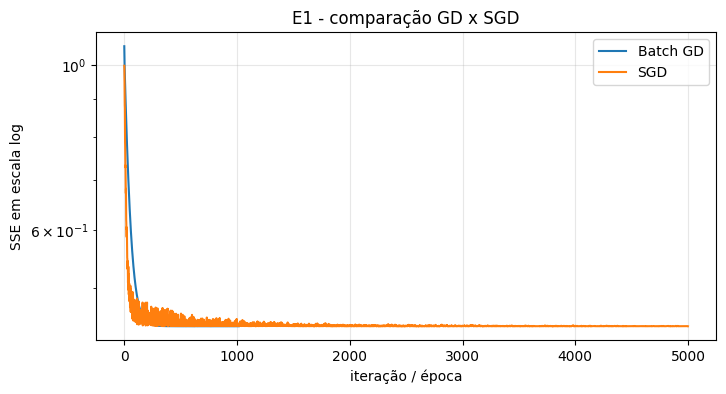

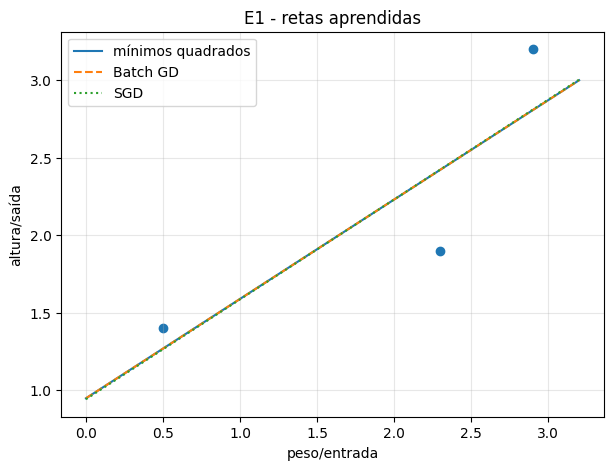

In [8]:

# E1 - Procedimento dos slides 301 a 325: regressão linear por gradiente descendente
x_sq = np.array([0.5, 2.3, 2.9], dtype=float)
y_sq = np.array([1.4, 1.9, 3.2], dtype=float)

def sse(b, m):
    return float(np.sum((y_sq - (b + m * x_sq)) ** 2))

def gradients_batch(b, m):
    residuals = y_sq - (b + m * x_sq)
    db = -2 * np.sum(residuals)
    dm = -2 * np.sum(residuals * x_sq)
    return db, dm

def batch_gradient_descent(lr=0.01, max_iter=100000, tol=1e-12):
    b, m = 0.0, 1.0
    history = []
    for step in range(max_iter):
        loss = sse(b, m)
        history.append(loss)
        db, dm = gradients_batch(b, m)
        b_new = b - lr * db
        m_new = m - lr * dm
        if abs(sse(b_new, m_new) - loss) < tol:
            b, m = b_new, m_new
            break
        b, m = b_new, m_new
    return b, m, history

def stochastic_gradient_descent(lr0=0.03, max_epochs=5000, tol=1e-10):
    rng = np.random.default_rng(SEED)
    b, m = 0.0, 1.0
    history = []
    prev = np.inf
    for epoch in range(max_epochs):
        lr = lr0 / (1 + 0.001 * epoch)
        for i in rng.permutation(len(x_sq)):
            pred = b + m * x_sq[i]
            residual = y_sq[i] - pred
            db = -2 * residual
            dm = -2 * residual * x_sq[i]
            b -= lr * db
            m -= lr * dm
        loss = sse(b, m)
        history.append(loss)
        if abs(prev - loss) < tol and epoch > 50:
            break
        prev = loss
    return b, m, history

b_batch, m_batch, hist_batch = batch_gradient_descent()
b_sgd, m_sgd, hist_sgd = stochastic_gradient_descent()
closed = np.linalg.lstsq(np.c_[np.ones_like(x_sq), x_sq], y_sq, rcond=None)[0]

print('Solução fechada por mínimos quadrados:')
print(f'intercepto={closed[0]:.6f}, inclinação={closed[1]:.6f}, SSE={sse(closed[0], closed[1]):.6f}')
print('\nBatch Gradient Descent:')
print(f'intercepto={b_batch:.6f}, inclinação={m_batch:.6f}, SSE={sse(b_batch, m_batch):.6f}, iterações={len(hist_batch)}')
print('\nStochastic Gradient Descent:')
print(f'intercepto={b_sgd:.6f}, inclinação={m_sgd:.6f}, SSE={sse(b_sgd, m_sgd):.6f}, épocas={len(hist_sgd)}')

plt.figure(figsize=(8,4))
plt.plot(hist_batch, label='Batch GD')
plt.plot(hist_sgd, label='SGD')
plt.yscale('log')
plt.xlabel('iteração / época')
plt.ylabel('SSE em escala log')
plt.title('E1 - comparação GD x SGD')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7,5))
plt.scatter(x_sq, y_sq)
xs = np.linspace(0, 3.2, 100)
plt.plot(xs, closed[0] + closed[1]*xs, label='mínimos quadrados')
plt.plot(xs, b_batch + m_batch*xs, linestyle='--', label='Batch GD')
plt.plot(xs, b_sgd + m_sgd*xs, linestyle=':', label='SGD')
plt.xlabel('peso/entrada')
plt.ylabel('altura/saída')
plt.title('E1 - retas aprendidas')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### Análise dos resultados - E1

O procedimento dos slides parte de um ponto inicial (`intercepto = 0`, `inclinação = 1`) e calcula o gradiente da soma dos resíduos quadráticos em relação aos dois parâmetros. O batch gradient descent usa todos os pontos para formar cada passo, por isso sua trajetória é mais estável e tende a se aproximar diretamente da solução de mínimos quadrados.

A versão estocástica atualiza os parâmetros usando um exemplo por vez. Isso torna o caminho mais ruidoso, mas mais parecido com o treinamento real de redes neurais em bases grandes. Como cada atualização observa apenas uma amostra, o SGD pode oscilar em torno do mínimo; por isso foi usada taxa de aprendizado decrescente. A comparação com a solução fechada permite validar se os dois algoritmos realmente se aproximam do mínimo da função de perda.

### Conclusão - E1

O gradiente descendente batch é mais suave e preciso neste problema pequeno. O gradiente descendente estocástico é mais ruidoso, mas executa atualizações frequentes e representa a lógica usada em mini-batches e redes neurais. Ambos minimizam a mesma função de perda, apenas com estimativas diferentes do gradiente.


## F1 - PyTorch e rede neural do StatQuest

### Slides do comando do problema

<p><img src="../slides_comando/slide_27.png" width="900"></p>
<p><img src="../slides_comando/slide_28.png" width="900"></p>
<p><img src="../slides_comando/slide_29.png" width="900"></p>


Saídas treinadas para dosagens de referência:
dosagem=0.00 -> saída=0.0161
dosagem=0.25 -> saída=0.1834
dosagem=0.50 -> saída=0.7002
dosagem=0.75 -> saída=0.2091
dosagem=1.00 -> saída=0.0459

Parâmetros finais:
fc1.weight [[ 9.6008]
 [-9.9922]]
fc1.bias [-6.6776  2.6239]
fc2.weight [[-5.4526 -6.7052]]
fc2.bias [2.1441]


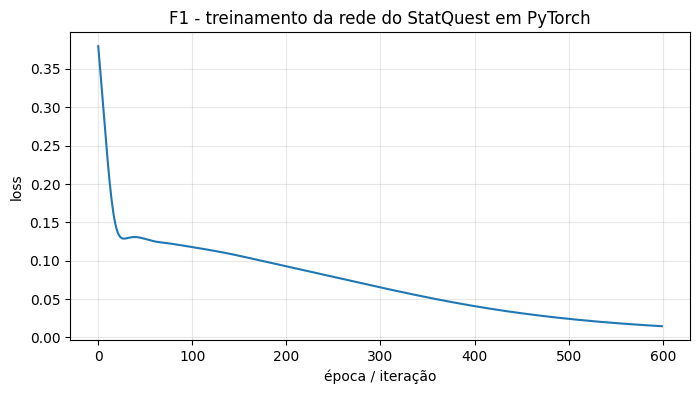

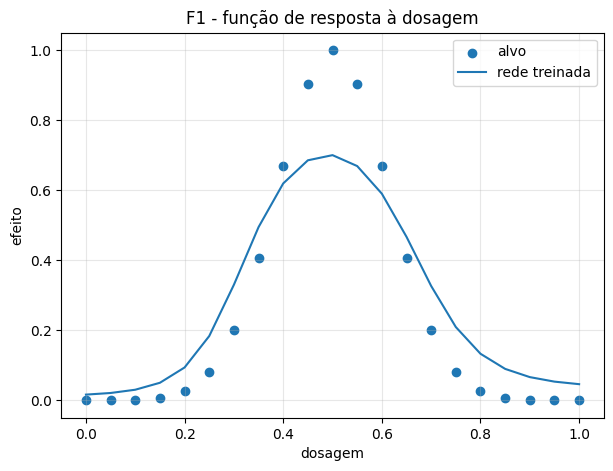

In [9]:

# F1 - Rede do StatQuest em PyTorch: 1 entrada, 2 neurônios ocultos sigmoidais e 1 saída
x_dose = torch.linspace(0, 1, 21).reshape(-1, 1)
y_effect = torch.exp(-((x_dose - 0.5) ** 2) / 0.025)
y_effect = y_effect / y_effect.max()

class StatQuestNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(1, 2)
        self.fc2 = nn.Linear(2, 1)
        with torch.no_grad():
            # Inicialização próxima dos valores mostrados nos slides do StatQuest.
            self.fc1.weight[:] = torch.tensor([[3.34], [-3.53]])
            self.fc1.bias[:] = torch.tensor([-1.43, 0.57])
            self.fc2.weight[:] = torch.tensor([[-1.22, -2.30]])
            self.fc2.bias[:] = torch.tensor([2.61])
    def forward(self, x):
        h = torch.sigmoid(self.fc1(x))
        return torch.sigmoid(self.fc2(h))

model_f1 = StatQuestNN()
opt_f1 = torch.optim.Adam(model_f1.parameters(), lr=0.03)
hist_f1 = []
for epoch in range(600):
    opt_f1.zero_grad()
    pred = model_f1(x_dose)
    loss = F.mse_loss(pred, y_effect)
    loss.backward()
    opt_f1.step()
    hist_f1.append(float(loss.detach()))

with torch.no_grad():
    probe = torch.tensor([[0.0], [0.25], [0.5], [0.75], [1.0]])
    probe_pred = model_f1(probe).numpy().ravel()
print('Saídas treinadas para dosagens de referência:')
for value, pred in zip(probe.numpy().ravel(), probe_pred):
    print(f'dosagem={value:.2f} -> saída={pred:.4f}')
print('\nParâmetros finais:')
for name, param in model_f1.named_parameters():
    print(name, param.detach().numpy().round(4))
plot_loss(hist_f1, 'F1 - treinamento da rede do StatQuest em PyTorch')

plt.figure(figsize=(7,5))
plt.scatter(x_dose.numpy(), y_effect.numpy(), label='alvo')
with torch.no_grad():
    plt.plot(x_dose.numpy(), model_f1(x_dose).numpy(), label='rede treinada')
plt.title('F1 - função de resposta à dosagem')
plt.xlabel('dosagem')
plt.ylabel('efeito')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### Análise dos resultados - F1

A rede do StatQuest é adequada para representar uma relação não linear do tipo “baixa dosagem não funciona, dosagem média funciona, dosagem alta volta a não funcionar”. Os dois neurônios ocultos criam regiões de ativação diferentes e a camada de saída combina essas regiões. A inicialização baseada nos valores dos slides acelera o treinamento porque já coloca a rede em uma forma aproximada de curva.

A saída esperada após o treinamento é baixa perto de `0`, alta perto de `0.5` e baixa novamente perto de `1`. Esse comportamento mostra que a rede não está aprendendo apenas uma reta; ela está usando as ativações sigmoidais para formar uma curva com pico central. A curva de perda confirma a redução do erro quadrático ao longo do treinamento.

### Conclusão - F1

A solução em PyTorch reproduz a ideia central da rede do StatQuest e mostra como os parâmetros podem ser ajustados automaticamente por backpropagation. A rede aprende uma função não linear simples e interpretável a partir de poucos dados sintéticos.


## G1 - Backpropagation

### Slides do comando do problema

<p><img src="../slides_comando/slide_30.png" width="900"></p>
<p><img src="../slides_comando/slide_31.png" width="900"></p>
<p><img src="../slides_comando/slide_32.png" width="900"></p>
<p><img src="../slides_comando/slide_33.png" width="900"></p>


Parâmetros finais manuais [w1,w2,w3,w4,b1,b2,b3]:
[-4.56123 -1.97492 -2.2716   2.1162   0.02902  1.19859 -0.50772]
Épocas manuais: 6000, MSE final: 0.06351478
PyTorch: épocas=6000, MSE final=0.06351490


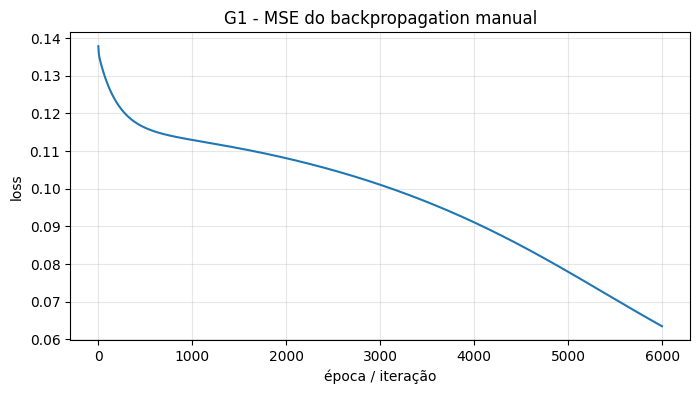

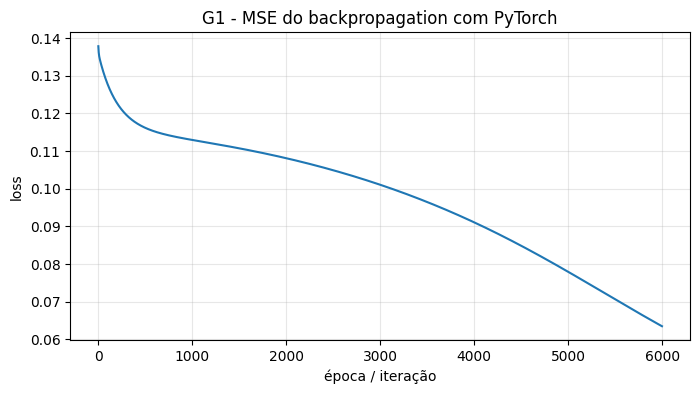

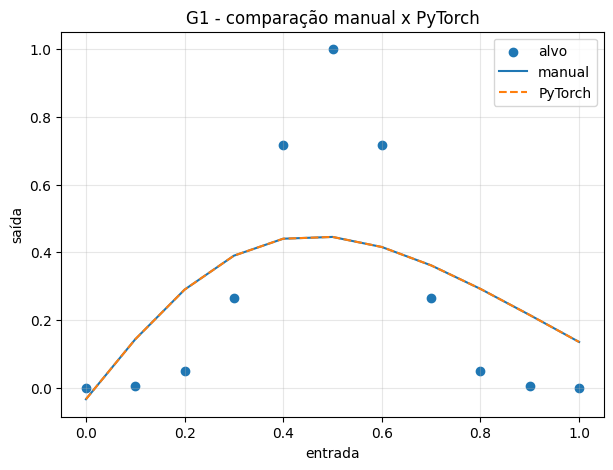

In [10]:

# G1 - Backpropagation manual da rede do slide: 1 entrada, 2 sigmoides ocultas, saída linear
xg = np.linspace(0, 1, 11).reshape(-1, 1)
yg = np.exp(-((xg - 0.5) ** 2) / 0.03)
yg = yg / yg.max()

# Inicialização explícita inspirada nos slides 178-187.
w1, w2, w3, w4 = -2.74, -1.13, 0.36, 0.63
b1, b2, b3 = 0.0, 0.0, 0.0
lr = 0.05
hist_g_manual = []

def forward_manual(x, params):
    w1, w2, w3, w4, b1, b2, b3 = params
    h1_in = w1 * x + b1
    h2_in = w2 * x + b2
    h1 = sigmoid_np(h1_in)
    h2 = sigmoid_np(h2_in)
    yhat = w3 * h1 + w4 * h2 + b3
    return h1, h2, yhat

for epoch in range(6000):
    params = (w1, w2, w3, w4, b1, b2, b3)
    h1, h2, yhat = forward_manual(xg, params)
    error = yg - yhat
    loss = np.mean(error ** 2)
    hist_g_manual.append(float(loss))

    # Gradientes da MSE média. Saída é linear; ocultas usam sigmoide.
    dL_dyhat = -2 * error / len(xg)
    dw3 = np.sum(dL_dyhat * h1)
    dw4 = np.sum(dL_dyhat * h2)
    db3 = np.sum(dL_dyhat)

    dh1 = dL_dyhat * w3
    dh2 = dL_dyhat * w4
    dz1 = dh1 * h1 * (1 - h1)
    dz2 = dh2 * h2 * (1 - h2)
    dw1 = np.sum(dz1 * xg)
    dw2 = np.sum(dz2 * xg)
    db1 = np.sum(dz1)
    db2 = np.sum(dz2)

    w1 -= lr * dw1; w2 -= lr * dw2; w3 -= lr * dw3; w4 -= lr * dw4
    b1 -= lr * db1; b2 -= lr * db2; b3 -= lr * db3
    if epoch > 100 and abs(hist_g_manual[-2] - hist_g_manual[-1]) < 1e-10:
        break

manual_params = np.array([w1, w2, w3, w4, b1, b2, b3])
print('Parâmetros finais manuais [w1,w2,w3,w4,b1,b2,b3]:')
print(manual_params.round(5))
print(f'Épocas manuais: {len(hist_g_manual)}, MSE final: {hist_g_manual[-1]:.8f}')

# Mesma rede em PyTorch
class BackpropTinyTorch(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(1, 2)
        self.fc2 = nn.Linear(2, 1)
        with torch.no_grad():
            self.fc1.weight[:] = torch.tensor([[-2.74], [-1.13]])
            self.fc1.bias[:] = torch.tensor([0.0, 0.0])
            self.fc2.weight[:] = torch.tensor([[0.36, 0.63]])
            self.fc2.bias[:] = torch.tensor([0.0])
    def forward(self, x):
        h = torch.sigmoid(self.fc1(x))
        return self.fc2(h)

model_g = BackpropTinyTorch()
opt_g = torch.optim.SGD(model_g.parameters(), lr=0.05)
xtg = torch.tensor(xg, dtype=torch.float32)
ytg = torch.tensor(yg, dtype=torch.float32)
hist_g_torch = []
for epoch in range(6000):
    opt_g.zero_grad()
    out = model_g(xtg)
    loss = F.mse_loss(out, ytg)
    loss.backward()
    opt_g.step()
    hist_g_torch.append(float(loss.detach()))
    if epoch > 100 and abs(hist_g_torch[-2] - hist_g_torch[-1]) < 1e-10:
        break

print(f'PyTorch: épocas={len(hist_g_torch)}, MSE final={hist_g_torch[-1]:.8f}')
plot_loss(hist_g_manual, 'G1 - MSE do backpropagation manual')
plot_loss(hist_g_torch, 'G1 - MSE do backpropagation com PyTorch')

plt.figure(figsize=(7,5))
plt.scatter(xg, yg, label='alvo')
_, _, yhat_manual = forward_manual(xg, tuple(manual_params))
plt.plot(xg, yhat_manual, label='manual')
with torch.no_grad():
    plt.plot(xg, model_g(xtg).numpy(), linestyle='--', label='PyTorch')
plt.title('G1 - comparação manual x PyTorch')
plt.xlabel('entrada')
plt.ylabel('saída')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### Análise dos resultados - G1

O primeiro caso deixa a inicialização explícita e implementa o backpropagation manualmente. A derivação segue a regra da cadeia: primeiro calcula-se o erro na saída, depois os gradientes dos pesos da camada de saída, e por fim o erro é propagado para as ativações sigmoidais da camada oculta. Como a saída é linear, os gradientes de `w3`, `w4` e `b3` dependem diretamente do erro e das ativações ocultas. Já os gradientes de `w1`, `w2`, `b1` e `b2` passam pela derivada da sigmoide.

A versão em PyTorch resolve a mesma rede com autograd. Comparar as curvas de perda e as predições finais é uma forma de validar o procedimento manual: se ambas reduzem o MSE e aproximam a curva-alvo, o cálculo manual está coerente. Pequenas diferenças podem surgir pela ordem de atualização, precisão numérica e critério de parada.

### Conclusão - G1

O item mostra que backpropagation não é uma “caixa preta”: ele é a aplicação sistemática da regra da cadeia para calcular derivadas em todas as camadas. A solução manual demonstra o mecanismo matemático, e a solução em PyTorch confirma o mesmo processo com diferenciação automática.
